Dual Augmentation (Trivial + Light) --> Tiny Swin v2 --> Attention-Guided Mixup --> ViT Head(LoRA-adapted Linear Classifier) --> PolyLoss + Label Smoothing --> SAM + Cosine LR Scheduler --> TTA

In [ ]:
# =========================
# FINAL PIPELINE
# =========================

import os
import glob
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

e:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Device: cpu


In [ ]:
# -------------------------
# 1) Paths & Basic Settings
# -------------------------
DATASET_DIR   = 'dataset'  
FEATURE_CSV_DIR = '.'          
IMG_SIZE      = 224

# Discover classes
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
assert len(CLASS_NAMES) > 1, "No class subfolders found in DATASET_DIR."
print('Classes:', CLASS_NAMES)

Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


In [ ]:
image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png')) + glob.glob(os.path.join(folder, '*.jpeg'))
    for p in imgs:
        image_paths.append(p)
        labels.append(lbl)

assert len(image_paths) > 0, "No images found."
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.2, random_state=42
)
print(f'Train images: {len(X_train_paths)} | Test images: {len(X_test_paths)}')

# Save ONLY required test metadata CSVs
pd.DataFrame({'path': X_test_paths, 'label': y_test}).to_csv(os.path.join(FEATURE_CSV_DIR, 'X_test_raw.csv'), index=False)
pd.DataFrame({'label': y_test}).to_csv(os.path.join(FEATURE_CSV_DIR, 'y_test.csv'), index=False)
print('Saved: X_test_raw.csv, y_test.csv')

Train images: 3200 | Test images: 800
Saved: X_test_raw.csv, y_test.csv


In [ ]:
# First augmentation: TrivialAugmentWide() or fallback RandomChoice([...])

# Second augmentation: RandomChoice([RandomResizedCrop, RandomVerticalFlip])
try:
    from torchvision.transforms import TrivialAugmentWide
    trivial_ok = True
except Exception:
    trivial_ok = False

train_augs = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
if trivial_ok:
    train_augs.append(TrivialAugmentWide())
else:
    # Fallback approximating TrivialAugmentWide
    train_augs.append(
        transforms.RandomChoice([
            transforms.RandomRotation(20),
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
            transforms.RandomAffine(degrees=0, translate=(0.1,0.1))
        ])
    )
# light second aug
train_augs.append(
    transforms.RandomChoice([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
        transforms.RandomVerticalFlip(p=0.5)
    ])
)
train_augs += [transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)]
train_transform = transforms.Compose(train_augs)

# Validation/Test (base transform)
base_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
# Test-Time Augmentation (TTA)
# A small, diverse set; logits are averaged at inference
tta_transforms = [
    base_test_transform,  # identity
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomHorizontalFlip(p=1.0),
                        transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)]),
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomRotation(10),
                        transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)]),
    transforms.Compose([transforms.CenterCrop(int(IMG_SIZE*0.95)), transforms.Resize((IMG_SIZE, IMG_SIZE)),
                        transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])
]

In [ ]:
# -------------------------------------------
# 5) Tiny Swin V2 Feature Extractor (frozen)
# -------------------------------------------
# Matches your pipeline: Tiny Swin V2
backbone_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(backbone_name, pretrained=True, num_classes=0)  # global pooled features
feature_model.eval().to(device)
for p in feature_model.parameters():
    p.requires_grad = False

@torch.no_grad()
def feat_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    f = feature_model(x)  # (1, D)
    return f.squeeze(0).cpu().numpy()

# Extract a single augmented pass for training features (as in your design)
X_train_feats = np.stack([feat_from_path(p, train_transform) for p in tqdm(X_train_paths, desc='Extract train feats')])
# We do NOT persist X_train/X_test feature CSVs anymore (per your requirement).

Extract train feats: 100%|██████████| 3200/3200 [08:58<00:00,  5.94it/s]


In [10]:
# ----------------------------------------------------------
# 6) Attention-Guided MixUp (feature-level, saliency-weighted)
# ----------------------------------------------------------
# We approximate per-feature "attention" using normalized absolute activation magnitude
# (stable and fast without needing gradients or internal attention maps).
# High-magnitude feature dimensions get higher weight when mixing.

def attention_guided_mixup_features(X, y, mixup_count, alpha=0.4):
    """
    X: (N, D) frozen backbone features
    y: (N,)
    Returns: mixed features (mixup_count, D), labels (mixup_count,)
    """
    N, D = X.shape
    X = X.astype(np.float32)
    # Precompute per-sample saliency vector s_i in [0,1]^D
    eps = 1e-8
    mag = np.abs(X)                         # (N, D)
    mag = mag / (mag.max(axis=1, keepdims=True) + eps)  # per-sample normalize
    saliency = mag                          # use as attention per-dimension

    mixX, mixy = [], []
    for _ in range(mixup_count):
        i, j = random.sample(range(N), 2)
        lam = np.random.beta(alpha, alpha)
        # Per-dimension attention weight: blend bias towards the more salient sample per dim
        a_ij = saliency[i]
        b_ij = saliency[j]
        # Normalize to get dim-wise mixing coefficients in [0,1]
        att = (a_ij + eps) / (a_ij + b_ij + 2*eps)     # higher when dim is more salient in sample i
        # Final per-dim lambda: convex combo of scalar lam and att
        lam_vec = 0.5 * lam + 0.5 * att                # (D,)
        mixed = lam_vec * X[i] + (1.0 - lam_vec) * X[j]
        mixX.append(mixed)
        # Using hard label of the "primary" sample (i). If you prefer soft targets, store (lam, y_i, y_j).
        mixy.append(y[i])
    return np.stack(mixX), np.array(mixy)

# As per your setup: use ONLY attention-guided mixed features for training
mixup_count = len(X_train_feats)  # e.g., 3200 for your dataset
X_mix, y_mix = attention_guided_mixup_features(X_train_feats, y_train, mixup_count=mixup_count, alpha=0.4)
X_final, y_final = X_mix, y_mix

# Persist ONLY required training CSVs
pd.DataFrame(X_final).to_csv(os.path.join(FEATURE_CSV_DIR, 'X_train_mixup.csv'), index=False)
pd.DataFrame({'label': y_final}).to_csv(os.path.join(FEATURE_CSV_DIR, 'y_train.csv'), index=False)
print('Saved: X_train_mixup.csv, y_train.csv')

Saved: X_train_mixup.csv, y_train.csv


In [ ]:
# LoRA-adapted linear classifier
class LoRALinear(nn.Module):
    """
    Simple LoRA head: y = W x + B + B_lora(A_lora x)
    Bias omitted to mirror your earlier design; easy to add if desired.
    """
    def __init__(self, in_features, out_features, r=8, alpha=1.0):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)
        # Optional scaling for LoRA path
        self.alpha = alpha

        # Init LoRA path small (as common in LoRA)
        nn.init.kaiming_uniform_(self.lora_a.weight, a=np.sqrt(5))
        nn.init.zeros_(self.lora_b.weight)

    def forward(self, x):
        base = self.linear(x)
        lora = self.lora_b(self.lora_a(x)) * self.alpha
        return base + lora

class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, r=8, alpha=1.0):
        super().__init__()
        self.head = LoRALinear(in_features, num_classes, r=r, alpha=alpha)
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(x).squeeze(0)
        return self.head(x)

In [ ]:
# PolyLoss + Label Smoothing

class Poly1LossWithSmoothing(nn.Module):
    def __init__(self, num_classes, epsilon=1.0, label_smoothing=0.1):
        super().__init__()
        self.epsilon = float(epsilon)
        self.label_smoothing = float(label_smoothing)
        self.num_classes = int(num_classes)

    def forward(self, logits, targets):
        # targets: (N,)
        targets_onehot = F.one_hot(targets, num_classes=self.num_classes).float()
        targets_smoothed = targets_onehot * (1 - self.label_smoothing) + self.label_smoothing / self.num_classes
        probs = F.softmax(logits, dim=-1)
        log_probs = torch.log(probs + 1e-8)
        ce = -(targets_smoothed * log_probs).sum(dim=-1).mean()
        poly1 = ce + self.epsilon * (1 - (probs * targets_smoothed).sum(dim=-1)).mean()
        return poly1

In [ ]:
# Optimizer (SAM) + Cosine LR Scheduler

try:
    from sam import SAM  
except Exception as e:
    raise ImportError("sam.py not found or failed to import.") from e

num_classes = len(CLASS_NAMES)
in_features = X_final.shape[1]

model_head = ViTHead(in_features=in_features, num_classes=num_classes, r=8, alpha=1.0).to(device)
criterion = Poly1LossWithSmoothing(num_classes=num_classes, epsilon=1.0, label_smoothing=0.1)

base_optimizer = torch.optim.Adam
optimizer = SAM(model_head.parameters(), base_optimizer, lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

e:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 01/20 | Loss: 2.4288
Epoch 02/20 | Loss: 2.0669
Epoch 03/20 | Loss: 1.9815
Epoch 04/20 | Loss: 1.9305
Epoch 05/20 | Loss: 1.8896
Epoch 06/20 | Loss: 1.8591
Epoch 07/20 | Loss: 1.8308
Epoch 08/20 | Loss: 1.8128
Epoch 09/20 | Loss: 1.7890
Epoch 10/20 | Loss: 1.7743
Epoch 11/20 | Loss: 1.7567
Epoch 12/20 | Loss: 1.7505
Epoch 13/20 | Loss: 1.7361
Epoch 14/20 | Loss: 1.7292
Epoch 15/20 | Loss: 1.7224
Epoch 16/20 | Loss: 1.7162
Epoch 17/20 | Loss: 1.7129
Epoch 18/20 | Loss: 1.7092
Epoch 19/20 | Loss: 1.7070
Epoch 20/20 | Loss: 1.7060


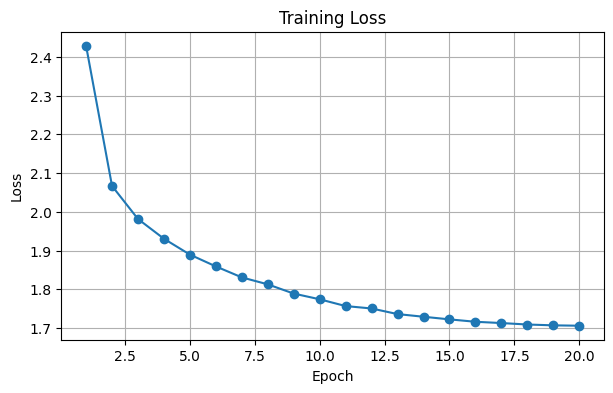

In [ ]:
# Training (features)

batch_size = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_final, dtype=torch.float32),
                  torch.tensor(y_final, dtype=torch.long)),
    batch_size=batch_size, shuffle=True
)

EPOCHS = 20
train_losses = []

for epoch in range(EPOCHS):
    model_head.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # SAM step 1
        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.first_step(zero_grad=True)

        # SAM step 2 (same batch)
        logits2 = model_head(xb)
        criterion(logits2, yb).backward()
        optimizer.second_step(zero_grad=True)

        total_loss += loss.item() * xb.size(0)

    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    scheduler.step()
    print(f'Epoch {epoch+1:02d}/{EPOCHS} | Loss: {epoch_loss:.4f}')

# Plot training curve
plt.figure(figsize=(7,4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [ ]:
# Evaluation with **TTA**

@torch.no_grad()
def tta_logits_for_image(path):
    """Average logits across TTA transforms."""
    logits_list = []
    img = Image.open(path).convert('RGB')
    for tfm in tta_transforms:
        x = tfm(img).unsqueeze(0).to(device)
        f = feature_model(x)                  # (1, D)
        logit = model_head(f)                 # (1, C)
        logits_list.append(logit)
    mean_logits = torch.stack(logits_list, dim=0).mean(0).squeeze(0)  # (C,)
    return mean_logits

# Inference over test set with TTA
model_head.eval()
all_logits = []
for p in tqdm(X_test_paths, desc='TTA Inference'):
    all_logits.append(tta_logits_for_image(p).cpu().numpy())

all_logits = np.stack(all_logits)                       # (N_test, C)
y_pred = all_logits.argmax(axis=1)

TTA Inference: 100%|██████████| 800/800 [05:42<00:00,  2.33it/s]


In [16]:
# Metrics
acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
print("\n===== RESULTS (with TTA) =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")


===== RESULTS (with TTA) =====
Accuracy : 0.9800
Precision: 0.9813
Recall   : 0.9800
F1 Score : 0.9802


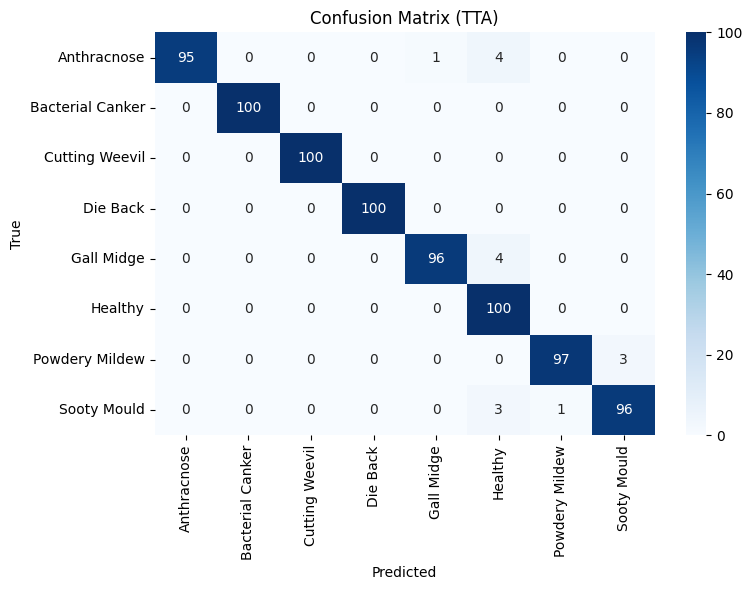

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=list(range(num_classes)))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (TTA)')
plt.tight_layout()
plt.show()